In [9]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
# from loglike_pure_noise import LogLike
# from loglike_phasemax_noise import LogLike
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 10
T = 24/12 #NOTE: changed!
N_SEGS = 12  # must match --n-segs used to build the LHS seed
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# # Source
# m1 = 1e6
# m2 = 1e1
# a = 0.7
# p0 = 9
# e0 = 0.4
# xI0 = 1.0
# dist = 4.5
# qS = np.pi
# phiS = 0.
# qK = 0.
# phiK = 0.
# Phi_phi0 = 0.4
# Phi_theta0 = 0.0
# Phi_r0 = 0.5    

# Mojito light EMRI_G
# m1 = 6.72e5
# m2 = 9.84e1
# a = 0.5
# p0 = 15.7117
# e0 = 0.7440
# xI0 = 1.0
# dist = 4.755
# qS = 0.5906
# phiS = 3.5808
# qK = 1.1707
# phiK = 3.8495
# Phi_phi0 = 3.1940
# Phi_theta0 = 3.3780
# Phi_r0 = 0.6038

def icrs_to_ecliptic(qK_icrs, phiK_icrs, eps_deg=23.43929111):
    """
    Convert a sky direction (colatitude, longitude) from the ICRS/equatorial
    frame (qK = pi/2 - dec, phiK = ra) to the ecliptic frame (SSB frame used
    by the LISA response, is_ecliptic_latitude=False convention) via the
    standard equatorial<->ecliptic rotation with J2000 mean obliquity eps.
    """
    dec = np.pi / 2 - qK_icrs
    ra = phiK_icrs
    eps = np.deg2rad(eps_deg)

    sin_beta = np.sin(dec) * np.cos(eps) - np.cos(dec) * np.sin(ra) * np.sin(eps)
    beta = np.arcsin(sin_beta)

    y = np.cos(dec) * np.sin(ra) * np.cos(eps) + np.sin(dec) * np.sin(eps)
    x = np.cos(dec) * np.cos(ra)
    lam = np.arctan2(y, x) % (2 * np.pi)

    qK_ecl = np.pi / 2 - beta
    phiK_ecl = lam
    return qK_ecl, phiK_ecl

# Mojito light EMRI_C
# m1 = 3.54e6
# m2 = 8.01e1
# a = 0.950
# p0 = 7.3890
# e0 = 0.3160
# xI0 = 1.0000
# dist = 4.858
# qS = 2.0420
# phiS = 5.7873
# qK, phiK = icrs_to_ecliptic(1.6633, 1.7431)  # catalog qK/phiK are in ICRS, convert to ecliptic
# Phi_phi0 = 2.4044
# Phi_theta0 = 0.2850
# Phi_r0 = 0.9743


# Mojito light EMRI_F
m1 = 1.00e7
m2 = 1.00e1
a = 0.998
p0 = 2.1200
e0 = 0.4250
xI0 = 1.0
dist = 4.313
qS = 0.6280
phiS = 1.2561
qK, phiK = icrs_to_ecliptic(2.7000, 2.6200)  # catalog qK/phiK are in ICRS, convert to ecliptic
Phi_phi0 = 4.1163
Phi_theta0 = 1.4444
Phi_r0 = 0.9810

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, np.cos(qS), phiS]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

# data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
# print(f'SNR (time-max): {data_snr:.4f}')

print("Setting up log_density and prior functions...")

# S schedule: jump to next S after stuck_iters of no improvement
S_schedule  = [3.0, 10.0, 30.0]
stuck_iters = 10000

# annealing dict
anneal_state = {
    'S':              S_schedule[0],
    'stage':          0,         # index into S_schedule
    'ref_max_ld':     None,      # max_ld at last check
    'ref_iter':       0,
    'stuck_count':    0,
}



def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, cos_qS_i, phiS_i = params[i]
        try:
            qS_i = np.arccos(cos_qS_i)
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS, phase_max=True))#*anneal_state['S']
        except Exception:
            pass
    return out



def prior_transform(u):
    # logm1lim = [5.6,  6.4]
    # logm2lim = [1.7, 2.3]
    # alim = [0.3, 0.99]
    # p0lim = [13.5, 16.5]
    # e0lim = [0.6, 0.9]
    # cosqSlim = [-1.0, 1.0]      # cos(qS): source colatitude, sampled uniform in cosine
    # phiSlim = [0.0, 2 * np.pi]

    # EMRI C
    # logm1lim = [6.15,  6.95]
    # logm2lim = [1.60,  2.20]
    # alim = [0.70,  0.999]
    # p0lim = [5.89,  8.89]
    # e0lim = [0.17,  0.47]
    # cosqSlim = [-1.0,  1.0]
    # phiSlim = [0.0,  2*np.pi]

    # EMRI F
    logm1lim = [6.6,   7.4]
    logm2lim = [0.7,   1.3]
    alim = [0.95,  0.999]
    p0lim = [1.8,   2.6]
    e0lim = [0.3,   0.55]
    cosqSlim = [-1.0,  1.0]
    phiSlim = [0.0,  2*np.pi]


    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    t[:, 5] = (cosqSlim[1] - cosqSlim[0]) * u[:, 5] + cosqSlim[0]
    t[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    return t


def inverse_prior_transform(params):
    # logm1lim = [5.6,  6.4]
    # logm2lim = [1.7, 2.3]
    # alim = [0.3, 0.99]
    # p0lim = [13.5, 16.5]
    # e0lim = [0.6, 0.9]
    # cosqSlim = [-1.0, 1.0]      # cos(qS): source colatitude, sampled uniform in cosine
    # phiSlim = [0.0, 2 * np.pi]

    # EMRI C
    # logm1lim = [6.15,  6.95]
    # logm2lim = [1.60,  2.20]
    # alim = [0.70,  0.999]
    # p0lim = [5.89,  8.89]
    # e0lim = [0.17,  0.47]
    # cosqSlim = [-1.0,  1.0]
    # phiSlim = [0.0,  2*np.pi]

    # EMRI F 
    logm1lim = [6.6,   7.4]
    logm2lim = [0.7,   1.3]
    alim = [0.95,  0.999]
    p0lim = [1.8,   2.6]
    e0lim = [0.3,   0.55]
    cosqSlim = [-1.0,  1.0]
    phiSlim = [0.0,  2*np.pi]

    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - cosqSlim[0]) / (cosqSlim[1] - cosqSlim[0])
    u[:, 6] = (params[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    return u


Using dt=10s, T=2.0yr, TDI gen=1, N_segs=12
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
Setting up log_density and prior functions...


In [10]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_f/stage1_anneal_s12/'


In [11]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [12]:
sampler.now_covariances

[array([[ 1.37290359e-05,  1.01244895e-06, -3.62970066e-06,
          4.50687087e-06,  5.20920324e-05,  4.21659846e-06,
         -7.12573778e-05],
        [ 1.01244895e-06,  3.75135193e-07,  2.25761713e-08,
         -1.51835897e-07,  4.56756678e-06,  2.10034857e-07,
         -6.66355691e-06],
        [-3.62970066e-06,  2.25761713e-08,  1.26537483e-06,
         -1.69780191e-06, -1.29691385e-05, -1.22435983e-06,
          1.73181227e-05],
        [ 4.50687087e-06, -1.51835897e-07, -1.69780191e-06,
          2.35020703e-06,  1.58561201e-05,  1.56875946e-06,
         -2.09803526e-05],
        [ 5.20920324e-05,  4.56756678e-06, -1.29691385e-05,
          1.58561201e-05,  2.00166642e-04,  1.57267796e-05,
         -2.74894474e-04],
        [ 4.21659846e-06,  2.10034857e-07, -1.22435983e-06,
          1.56875946e-06,  1.57267796e-05,  1.34116725e-06,
         -2.13695119e-05],
        [-7.12573778e-05, -6.66355691e-06,  1.73181227e-05,
         -2.09803526e-05, -2.74894474e-04, -2.13695119e-05

In [13]:
len(sampler.now_covariances)

1

In [14]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.90378929, 0.77947866, 0.99250376, 2.50282304, 0.5132773 ,
        0.03624287, 1.00126148]])

In [15]:
log_density(maxld_pt1)

array([18.2361562])

In [16]:
log_density([param_true])

array([55.47636735])

In [17]:
param_ranges = [(6.6,   7.4),
                (0.7,   1.3),
                (0.95,  0.999),
                (1.8,   2.6),
                (0.3,   0.55),
                (-1,1),
                (0.0, 2 * np.pi)
                ]
param_ranges

[(6.6, 7.4),
 (0.7, 1.3),
 (0.95, 0.999),
 (1.8, 2.6),
 (0.3, 0.55),
 (-1, 1),
 (0.0, 6.283185307179586)]

In [18]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,np.cos(qS),phiS]
param_true

[7.0, 1.0, 0.998, 2.12, 0.425, 0.8092041809880323, 1.2561]

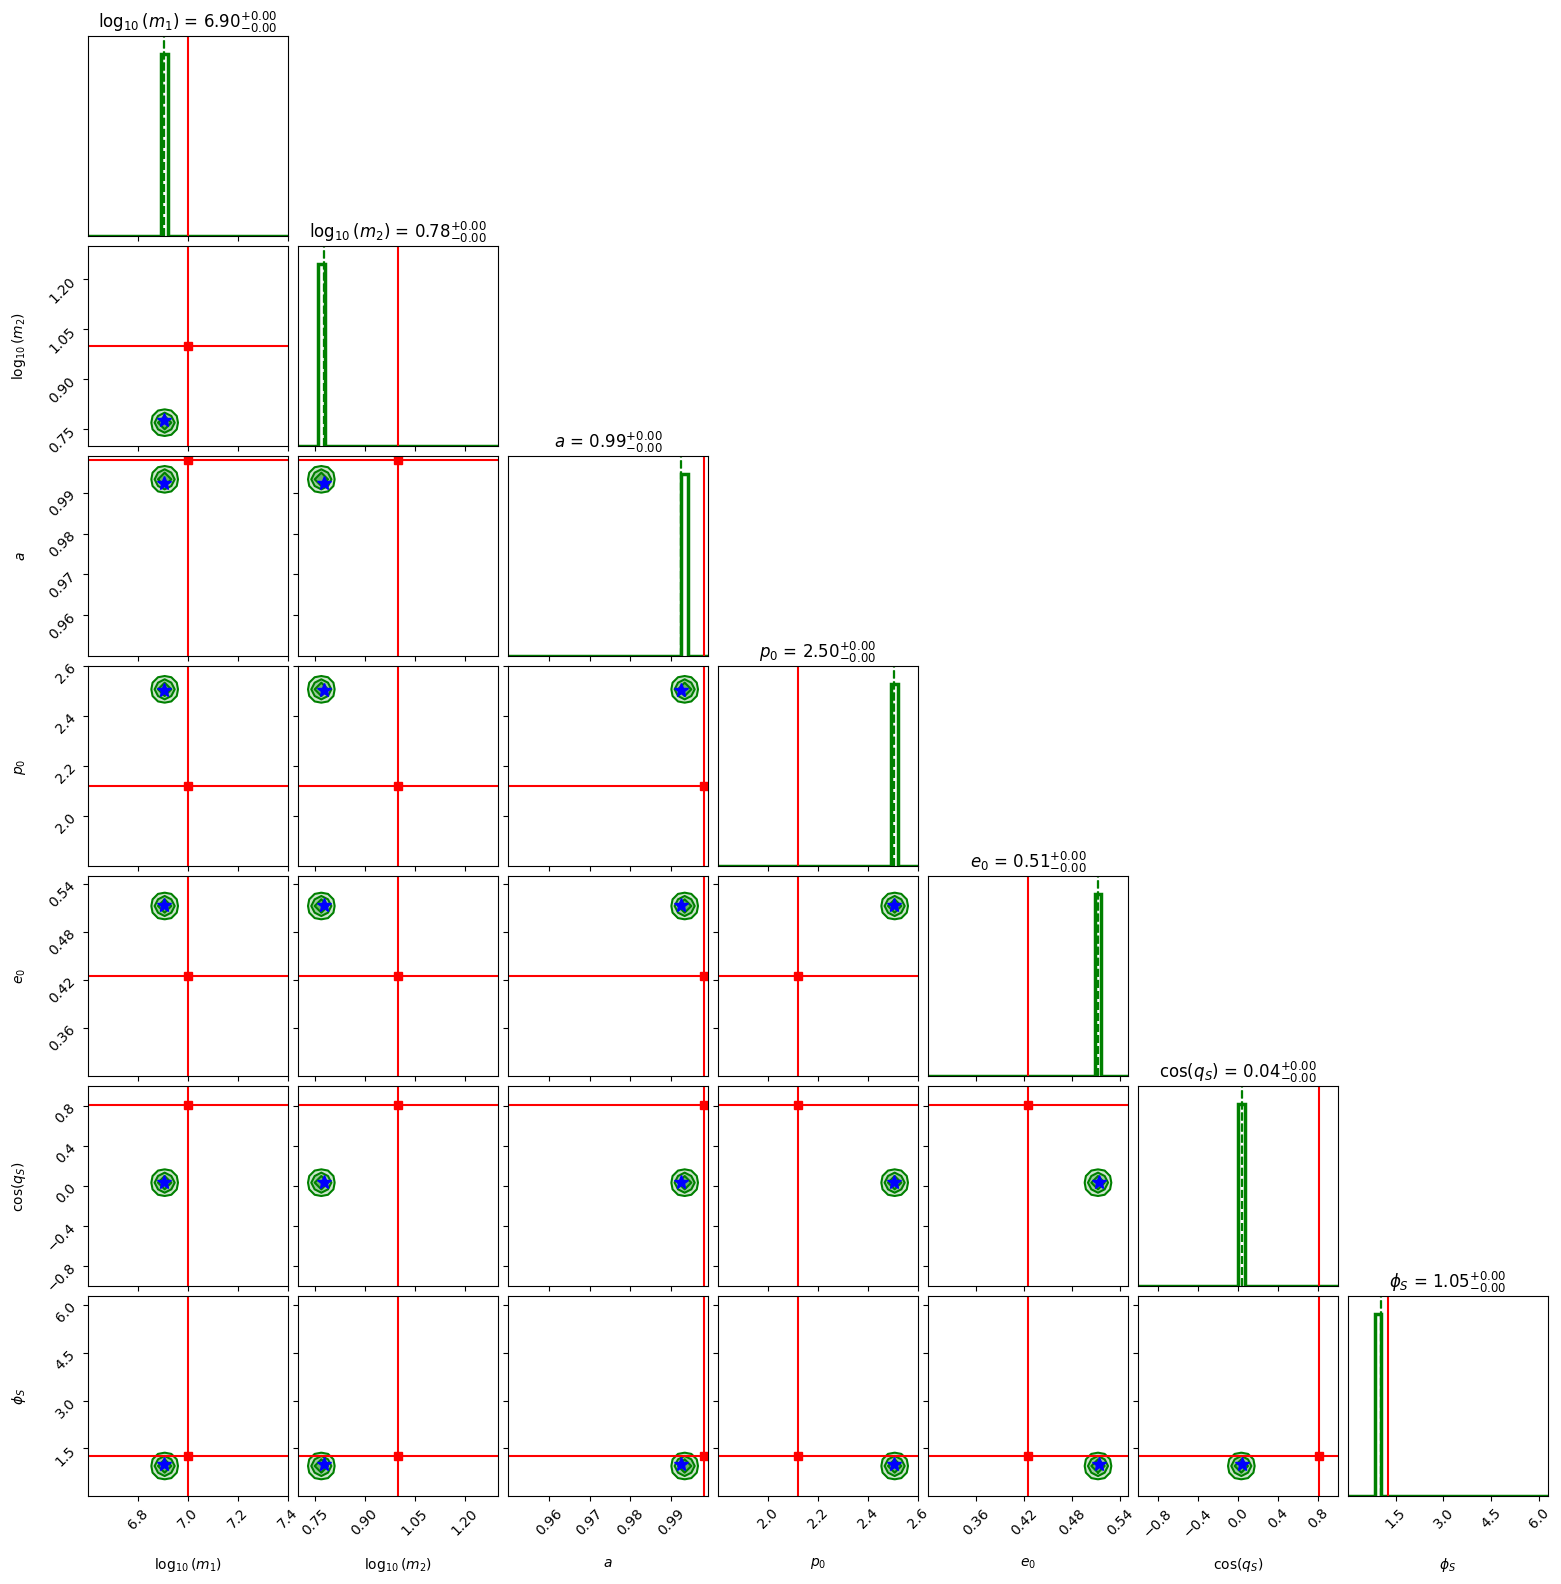

In [19]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$\cos(q_S)$', r'$\phi_S$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)


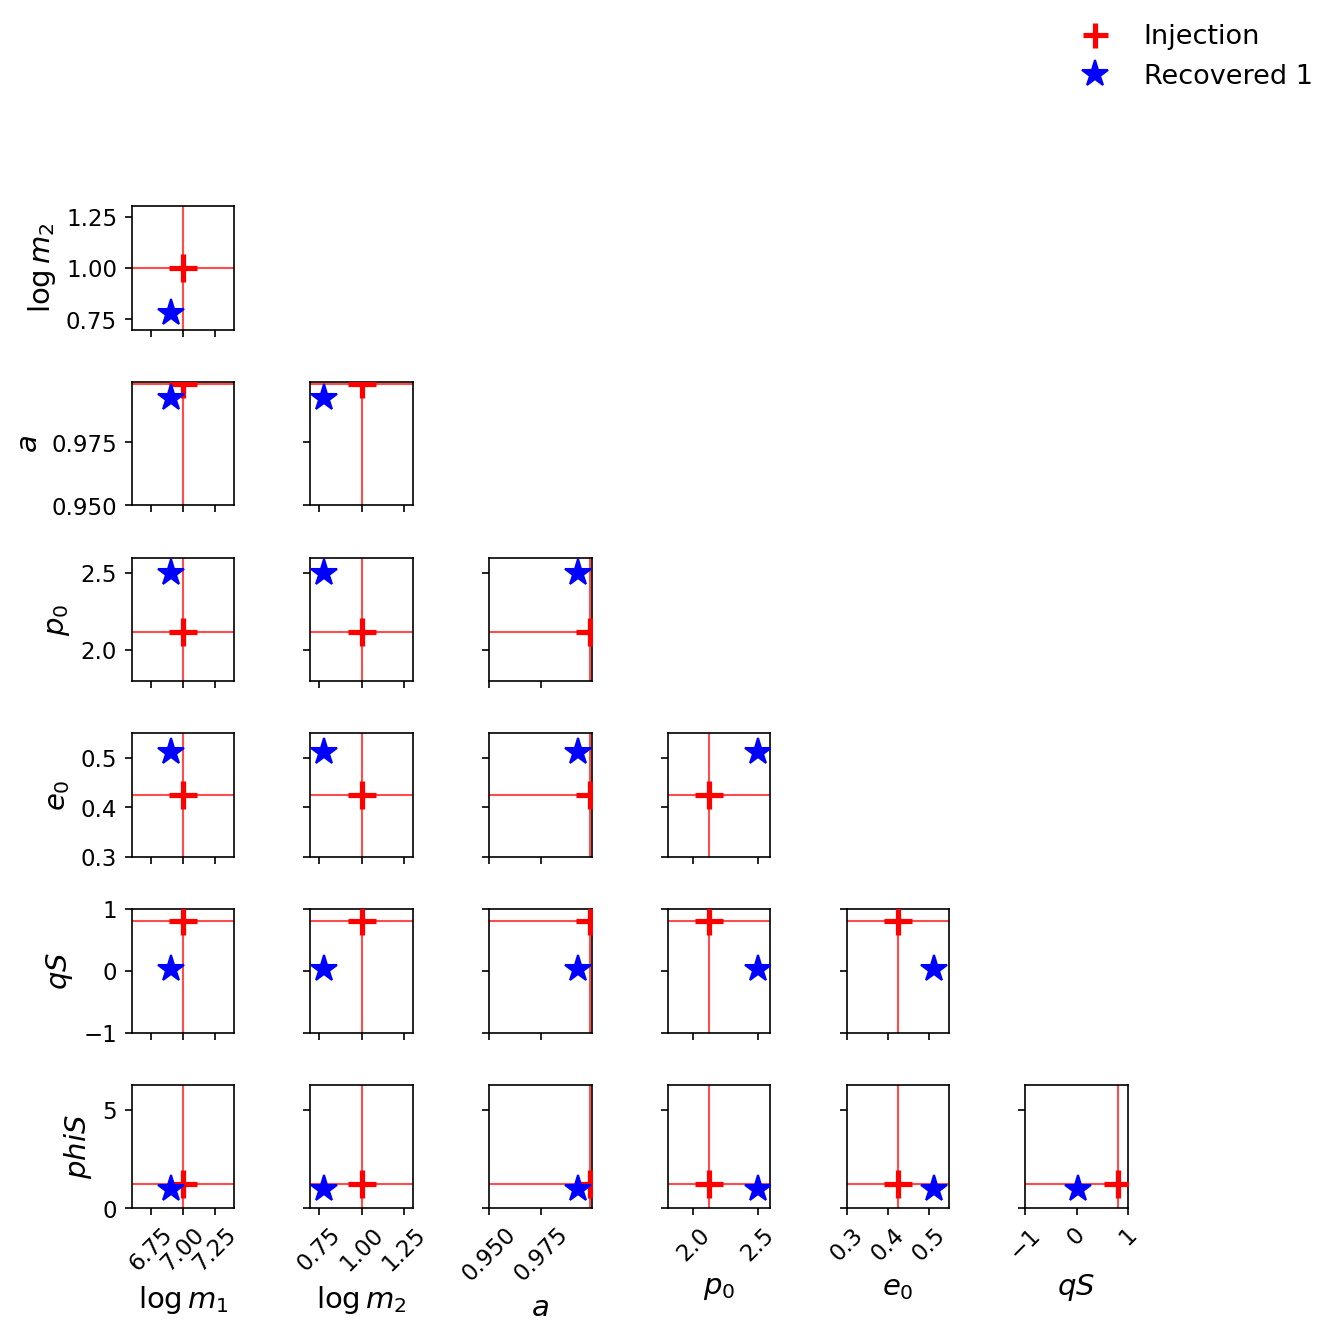

In [20]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()


# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered 1'),
    # Line2D([0], [0], color='orange', marker='*', ls='', ms=13,          label='Recovered 2'),
    # Line2D([0], [0], color='pink', marker='*', ls='', ms=13,          label='Recovered 3'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot to proc 1

In [21]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[6.90378929, 0.77947866, 0.99250376, 2.50282304, 0.5132773 ,
        0.03624287, 1.00126148]])

In [22]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [23]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [24]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


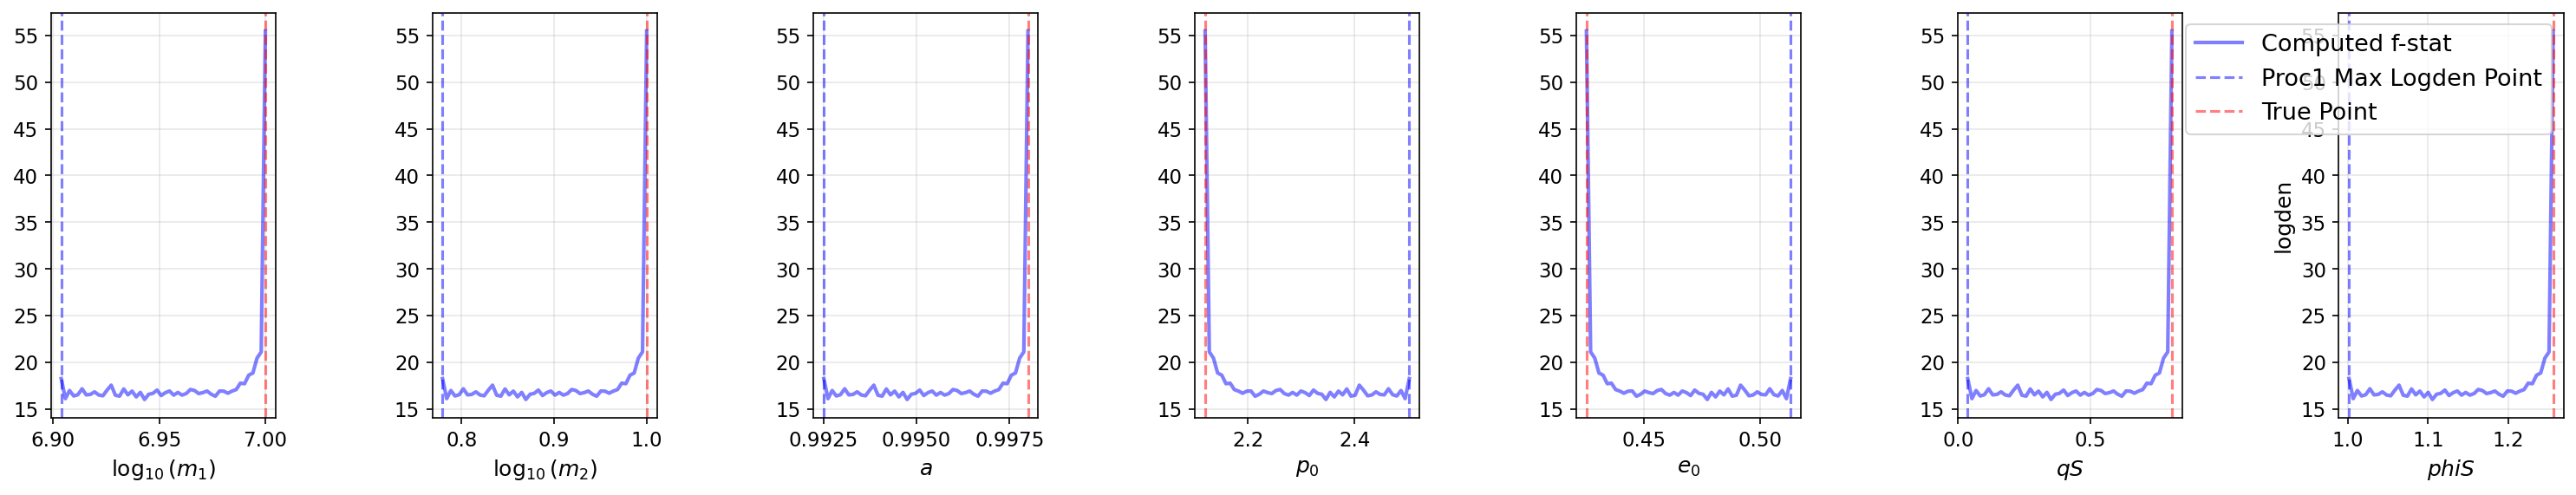

In [25]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [26]:
import numpy as np

def sky_antipode(qS, phiS):
    """
    Antipodal sky point: qS -> pi - qS, phiS -> phiS + pi (mod 2pi).
    qS: colatitude [rad], phiS: azimuth [rad].
    """
    qS_anti = np.pi - qS
    phiS_anti = (phiS + np.pi) % (2 * np.pi)
    return qS_anti, phiS_anti

# EMRI_C true values
qS_true, phiS_true = 2.0420, 5.7873
qS_anti, phiS_anti = sky_antipode(qS_true, phiS_true)

print(f"qS_true={qS_true:.4f}  phiS_true={phiS_true:.4f}  cos(qS_true)={np.cos(qS_true):.5f}")
print(f"qS_anti={qS_anti:.4f}  phiS_anti={phiS_anti:.4f}  cos(qS_anti)={np.cos(qS_anti):.5f}")


qS_true=2.0420  phiS_true=5.7873  cos(qS_true)=-0.45396
qS_anti=1.0996  phiS_anti=2.6457  cos(qS_anti)=0.45396


In [27]:
maxld_pt1

array([6.90378929, 0.77947866, 0.99250376, 2.50282304, 0.5132773 ,
       0.03624287, 1.00126148])

In [28]:
# Bootstrap-resample the weighted posterior (same as paris3_lhs_s6_ext.py)
weights_norm = weights / weights.sum()
rng_rs = np.random.default_rng(0)
idx_rs = rng_rs.choice(len(samples), size=50_000, replace=True, p=weights_norm)
cov_posterior = np.cov(samples[idx_rs].T)
sigma_diag = np.sqrt(np.diag(cov_posterior))

mu_center = maxld_pt1.ravel()          # max-log-density point (== mu_center in the script)
param_true_arr = np.asarray(param_true).ravel()

n_sigma_needed = (param_true_arr - mu_center) / sigma_diag

param_names = ['logm1', 'logm2', 'a', 'p0', 'e0', 'cos_qS', 'phiS']
for name, mu, sig, ns in zip(param_names, mu_center, sigma_diag, n_sigma_needed):
    print(f'{name:8s}: mu={mu:.5f}  sigma={sig:.5f}  true offset = {ns:+.2f} sigma')

print(f'\nMax |N_sigma| across dims (box would need N_SIGMA >= this to contain truth): '
      f'{np.max(np.abs(n_sigma_needed)):.2f}')

logm1   : mu=6.90379  sigma=0.00296  true offset = +32.53 sigma
logm2   : mu=0.77948  sigma=0.00033  true offset = +662.72 sigma
a       : mu=0.99250  sigma=0.00005  true offset = +102.69 sigma
p0      : mu=2.50282  sigma=0.00117  true offset = -326.72 sigma
e0      : mu=0.51328  sigma=0.00353  true offset = -24.99 sigma
cos_qS  : mu=0.03624  sigma=0.00229  true offset = +337.02 sigma
phiS    : mu=1.00126  sigma=0.12203  true offset = +2.09 sigma

Max |N_sigma| across dims (box would need N_SIGMA >= this to contain truth): 662.72


In [32]:
# Prior bounds (same as paris3_lhs_s6_ext.py / stage1_anneal_s12 prior)
p1_lo = np.array([6.6, 0.7, 0.95, 1.8, 0.3, -1.0, 0.0])
p1_hi = np.array([6.95, 2.20, 0.999, 8.89, 0.47, 1.0, 2 * np.pi])

# N_SIGMA needed to cover the true point (from previous cell), rounded up
N_SIGMA = 700
print(f'N_SIGMA = {N_SIGMA:.0f}')

ellipse_lo = np.clip(mu_center - N_SIGMA * sigma_diag, p1_lo, p1_hi)
ellipse_hi = np.clip(mu_center + N_SIGMA * sigma_diag, p1_lo, p1_hi)
box_width  = ellipse_hi - ellipse_lo
full_width = p1_hi - p1_lo

param_names = ['logm1', 'logm2', 'a', 'p0', 'e0', 'cos_qS', 'phiS']
for name, lo, hi, w, fw in zip(param_names, ellipse_lo, ellipse_hi, box_width, full_width):
    print(f'{name:8s}: [{lo:.5f}, {hi:.5f}]  width={w:.5f}  '
          f'({100*w/fw:.2f}% of full prior width)')

vol_frac = np.prod(box_width / full_width)
print(f'\nBox volume fraction of full prior box: {vol_frac:.3e}  (log10 = {np.log10(vol_frac):.2f})')


N_SIGMA = 700
logm1   : [6.60000, 6.95000]  width=0.35000  (100.00% of full prior width)
logm2   : [0.70000, 1.01241]  width=0.31241  (20.83% of full prior width)
a       : [0.95504, 0.99900]  width=0.04396  (89.72% of full prior width)
p0      : [1.80000, 3.32303]  width=1.52303  (21.48% of full prior width)
e0      : [0.30000, 0.47000]  width=0.17000  (100.00% of full prior width)
cos_qS  : [-1.00000, 1.00000]  width=2.00000  (100.00% of full prior width)
phiS    : [0.00000, 6.28319]  width=6.28319  (100.00% of full prior width)

Box volume fraction of full prior box: 4.014e-02  (log10 = -1.40)
